# Quantum Circuit to Estimate Pi Using Quantum Amplitude Estimation 

## Introduction

Monte Carlo computation is an indispensable simulation technique across a wide range of modern scientific and technological fields, including financial modeling, radiation transport, AI, and computer graphics. In conventional Monte Carlo methods using classical computers, there is a fundamental limitation: achieving a desired estimation error $\epsilon$ requires a computational cost of $O(1/\epsilon^{2})$. In contrast, it has been mathematically proven that by using Quantum Amplitude Estimation (QAE), a type of quantum algorithm, this cost can be reduced to the square-root order $O(1/\epsilon)$. As a result, QAE has attracted significant attention as a next-generation high-speed computational method.

In this notebook, we focus on estimating $\pi$, a representative example of Monte Carlo computation, and investigate its implementation using quantum circuits as well as its performance characteristics. Specifically, instead of standard random sampling, we adopt a method based on uniformly spaced sampling in each dimension. This choice has two important advantages: it highlights the intrinsic features of quantum algorithms and provides a framework for addressing the curse of dimensionality in multidimensional numerical integration.

First, by applying Hadamard gates, it is straightforward to generate a superposition of $2^{n}$ computational basis states on an $n$-qubit register. This enables operations to be performed while all sampling points are held in parallel, which is mathematically equivalent to a numerical integration framework in which all lattice-like sampling points in a multidimensional space are evaluated simultaneously.

Second, this approach clarifies the benchmark for quantum speedup. In classical multidimensional numerical integration, as the dimension $d$ of the problem increases, the number of required samples $N$ grows exponentially, on the order of $O(1/\epsilon_{s}^{d})$. In contrast, quantum algorithms can increase the number of samples exponentially by increasing the number of qubits only linearly, giving them a particularly strong advantage for high-dimensional problems.

To examine in an integrated manner both the improved convergence provided by QAE and the enhanced spatial sampling efficiency enabled by qubits, we adopt a sampling method based on lattice-like superposition states. This approach goes beyond the mere estimation of $\pi$ and serves as a practical model case for considering how fault-tolerant quantum computers, once realized, may overcome the computational resource limitations currently faced in complex simulations and real-world financial applications.

## Method

In classical Monte Carlo computation, a problem is solved by repeatedly performing random sampling and estimating an expectation value. The accuracy improves as the number of samples increases, and obtaining an estimate with error $\epsilon$ requires $O(1/\epsilon^{2})$ samples.

In quantum computing, expectation values can be evaluated more efficiently using Quantum Amplitude Estimation (QAE). Let $x \in {0,1}^{n}$ be an $n$-bit binary variable, $f(x)$ a classical real-valued function, and $p(x)$ a probability distribution. Then the expectation value of $f(x)$ is given by
$$
E[f(x)] = \sum_{x=0}^{2^{n}-1} f(x)p(x). \tag{9}
$$

Classically, estimating this quantity with error $\epsilon$ requires $O(1/\epsilon^{2})$ samples. In the quantum setting, we introduce a unitary operator $\hat{R}$ acting on an $n$-qubit first register $|x\rangle_{1}$ and a one-qubit second register $|0\rangle_{2}$ such that
$$
\hat{R}|x\rangle_{1}|0\rangle_{2}=
\sqrt{f(x)}|x\rangle_{1}|1\rangle_{2}
+
\sqrt{1-f(x)}|x\rangle_{1}|0\rangle_{2}.
$$

We also prepare a unitary operator $\hat{P}$ that maps the initialized first register to
$$
\hat{P}|0\rangle_{1}=
\sum_{x=0}^{2^{n}-1} \sqrt{p(x)}|x\rangle_{1}.
$$

Applying $\hat{P}$ and $\hat{R}$ to the initialized state gives
$$
\hat{R}(\hat{P} \otimes I_{2})|0\rangle_{1}|0\rangle_{2}=
\sum_{x=0}^{2^{n}-1} \sqrt{f(x)p(x)},|x\rangle_{1}|1\rangle_{2}
+
\sum_{x=0}^{2^{n}-1} \sqrt{(1-f(x))p(x)},|x\rangle_{1}|0\rangle_{2}.
$$

Thus, the amplitude of the component with the second register in state $|1\rangle_{2}$ encodes $E[f(x)]$, and the probability of measuring $|1\rangle_{2}$ is exactly equal to the expectation value. By estimating this amplitude using QAE, one can obtain $E[f(x)]$ more efficiently than in the classical Monte Carlo approach.


As in the well-known classical Monte Carlo method for estimating $\pi$, we compute $\pi$ from the area ratio between a square and a quarter circle sharing two of its sides. Suppose that the two shared sides of the square and the quarter circle lie on the $x$- and $y$-axes, respectively, and that the coordinates $(x,y)$ on the plane are each represented by $n$ qubits. Since $x$ and $y$ can each take values
$$
0 \le x \le 2^{n}-1, \qquad 0 \le y \le 2^{n}-1,
$$
they can represent the $2^{2n}$ coordinates inside a square with side length $2^{n}$. Figure 8 illustrates the sampling scheme, in which the black dots representing the sample coordinates are arranged at uniform intervals.

Furthermore, we require a function $f(x,y)$ that returns $1$ when a given $(x,y)$ lies inside the quarter circle of radius $2^{n}$, and returns $0$ otherwise:
$$
f(x, y) =
\begin{cases}
1 & \text{if } x^{2} + y^{2} < 2^{2n}, \\
0 & \text{if } x^{2} + y^{2} \ge 2^{2n}.
\end{cases}
$$

Let $p(x,y)$ denote the probability distribution for sampling. Then, the fraction of all sample points that fall inside the quarter circle gives an estimate of the area ratio. Therefore,
$$
\frac{\pi}{4} \approx \sum_{y=0}^{2^{n}-1} \sum_{x=0}^{2^{n}-1} f(x,y),p(x,y)
$$
holds.


## Dataset

We first generate the grid data.  $n$ is the parameter for number of data.

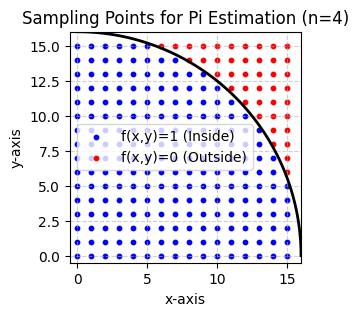

In [1]:
import matplotlib.pyplot as plt
import numpy as np


def plot_pi_sampling(n):
    limit = 2**n
    x_range = np.arange(limit)
    y_range = np.arange(limit)

    X, Y = np.meshgrid(x_range, y_range)

    # constraint: f(x, y) = 1 (True) if x^2 + y^2 < limit^2
    inside = X**2 + Y**2 < limit**2

    plt.figure(figsize=(3, 3))

    # data plot
    plt.scatter(X[inside], Y[inside], color="blue", s=10, label="f(x,y)=1 (Inside)")
    plt.scatter(X[~inside], Y[~inside], color="red", s=10, label="f(x,y)=0 (Outside)")

    theta = np.linspace(0, np.pi / 2, 100)
    plt.plot(limit * np.cos(theta), limit * np.sin(theta), color="black", linewidth=2)

    plt.xlim(-0.5, limit)
    plt.ylim(-0.5, limit)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.title(f"Sampling Points for Pi Estimation (n={n})")
    plt.xlabel("x-axis")
    plt.ylabel("y-axis")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()


plot_pi_sampling(n=4)

## Simulation: Classical Simulation

Below, as a point of comparison, we first present an example of a classical simulation based on uniformly spaced sampling points.


In [2]:
def estimate_pi_grid(n):
    limit = 2**n
    inside_circle = 0
    total_samples = limit * limit

    for y in range(limit):
        for x in range(limit):
            if x**2 + y**2 < limit**2:
                inside_circle += 1

    pi_estimated = (inside_circle / total_samples) * 4
    return pi_estimated


n = 6
print(f"n={n} (Samples: {2**(2*n)}), Estimated Pi: {estimate_pi_grid(n)}")

n=6 (Samples: 4096), Estimated Pi: 3.19921875


## Quantum Simulation
### Option 1: QAE based QMCI

In [15]:
import numpy as np

from classiq import *

n = 3


class position(QStruct):
    x: QNum[n]
    y: QNum[n]


@qfunc
def encode_prob(p: position):
    hadamard_transform(p)


@qperm
def oracle_func(p: Const[position], res: QBit):
    fn = 2 ** (2 * n)
    res ^= p.x**2 + p.y**2 < fn


@qfunc
def oracle_op(state: position):
    phase_oracle(oracle_func, state)


@qfunc
def my_grover_operator(state: position):
    grover_operator(
        oracle_op,
        hadamard_transform,
        state,
    )


QPE_SIZE = 3


@qfunc
def main(phase_reg: Output[QNum[QPE_SIZE, UNSIGNED, QPE_SIZE]]):
    state_reg = position()
    allocate(state_reg.size, state_reg)

    allocate(phase_reg)
    encode_prob(state_reg)
    qpe(
        unitary=lambda: my_grover_operator(state_reg),
        phase=phase_reg,
    )
    drop(state_reg)


qprog = synthesize(main)
show(qprog)

Quantum program link: https://platform.classiq.io/circuit/3BOg5WCtXKA5Mdxa7nKD3vt3M3S


https://platform.classiq.io/circuit/3BOg5WCtXKA5Mdxa7nKD3vt3M3S?login=True&version=18

In [4]:
result = execute(qprog).result_value()
phases_counts = dict(
    (sampled_state.state["phase_reg"], sampled_state.shots)
    for sampled_state in result.parsed_counts
)

In [19]:
expected_alpha = np.sin(np.pi * max(phases_counts, key=phases_counts.get))
print("QMCI pi = ", expected_alpha * 4)
print("exact pi = ", np.pi)

QMCI pi =  3.695518130045147
exact pi =  3.141592653589793


This result indicates that QMCI successfully approaches the value of $\pi$, although the current estimate still has a significant error compared with the exact value. In the next cell, we investigate how accurately $\pi$ can be estimated by applying IQAE and examining its achievable precision.

### Option2: Iterative QAE based QMCI

In [19]:
from classiq.applications.iqae.iqae import IQAE


def iqae_circuit(num_qubits):
    class position(QStruct):
        x: QNum[num_qubits]
        y: QNum[num_qubits]

    @qfunc
    def encode_prob(p: position):
        hadamard_transform(p)

    @qperm
    def oracle_func(p: Const[position], res: QBit):
        fn = 2 ** (2 * num_qubits)
        res ^= p.x**2 + p.y**2 < fn

    @qfunc
    def iqae_state_preparation(p: position, ind: QBit):
        encode_prob(p)
        oracle_func(p, ind)

    iqae = IQAE(
        state_prep_op=iqae_state_preparation,
        problem_vars_size=2 * num_qubits,
        constraints=Constraints(max_width=30),  # optimization_parameter="width"),
        preferences=Preferences(machine_precision=num_qubits),
    )
    return iqae

In [6]:
num_qubits = 3
qprog = iqae_circuit(num_qubits).get_qprog()
show(qprog)

Quantum program link: https://platform.classiq.io/circuit/3BOdbag8tz3lZ8QkBmLpPbqaVBE


https://platform.classiq.io/circuit/3BOdbag8tz3lZ8QkBmLpPbqaVBE?login=True&version=18

### IQAE Parameters

* $\epsilon$ (accuracy):

  * In the paper, the estimation accuracy for $k_{\max}=5$ is $O(10^{-3})$. Therefore, setting $\epsilon$ to around $0.001$ corresponds to attempting a high-precision estimation with a computational cost close to that reported in the paper. For an initial test, a looser value such as $0.01$ (roughly corresponding to $k_{\max}=1$ in the paper) is more suitable.
* $\alpha$ (confidence interval / failure probability):

  * This parameter specifies the probability that the estimate falls outside the $\epsilon$ range. Common choices are $0.05$ (95% confidence level) or $0.01$ (99% confidence level).


In [8]:
iqae_res = iqae_circuit(num_qubits).run(epsilon=0.03, alpha=0.01)

In [9]:
iqae_res.confidence_interval

[0.870376089433495, 0.8785499793631046]

In [10]:
iqae_res.estimation * 4

3.497852137593199

The factor of $4$ is required because IQAE estimates $\pi/4$, corresponding to the area ratio of the quarter circle inside the square.

### Experiment

In this experiment, we examine whether the estimated value approaches the exact solution as the number of qubits increases. Because a larger number of qubits allows exponentially more sampling points to be represented, the discretization becomes finer, and the estimate is expected to become more accurate. By tracking this trend, we can directly evaluate how increasing the qubit number improves the precision of the $\pi$ estimation.


In [1]:
# list_expected_value = []
# list_conf_err = []
# for num_qubits in range(1,5):
#     iqae_res = iqae_circuit(num_qubits).run(epsilon=0.03, alpha=0.01)
#     print("expected pi =", iqae_res.estimation * 4)
#     list_expected_value.append(iqae_res.estimation * 4)
#     list_conf_err.append(iqae_res.confidence_interval)

When you run the cell above, you should obtain results similar to those shown below:

In [3]:
list_expected_value = [
    3.998328879248948,
    3.7572795311895337,
    3.5043386707175443,
    3.3476167564481774,
]
list_conf_err = [
    [0.999164439624474, 1.0],
    [0.9328714567271077, 0.9457683088676591],
    [0.8720696958863934, 0.8800996394723789],
    [0.8298663183601778, 0.8439420598639109],
]

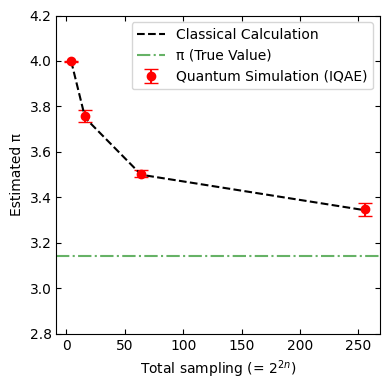

In [4]:
import matplotlib.pyplot as plt
import numpy as np

n_list = range(1, 5)
total_sampling = [2 ** (2 * n) for n in n_list]

pi_ests = list_expected_value

yerr_lower = [pi_ests[i] - (list_conf_err[i][0] * 4) for i in range(len(pi_ests))]
yerr_upper = [(list_conf_err[i][1] * 4) - pi_ests[i] for i in range(len(pi_ests))]

plt.figure(figsize=(4, 4))
plt.tick_params(direction="in", which="both", top=True, right=True)

plt.errorbar(
    total_sampling,
    pi_ests,
    yerr=[yerr_lower, yerr_upper],
    fmt="o",
    color="red",
    capsize=5,
    markersize=6,
    label="Quantum Simulation (IQAE)",
)


def classical_grid_pi(n):
    limit = 2**n
    inside = sum(
        1 for y in range(limit) for x in range(limit) if x ** 2 + y**2 < limit**2
    )
    return (inside / limit**2) * 4


classical_pi_vals = [classical_grid_pi(n) for n in n_list]
plt.plot(
    total_sampling,
    classical_pi_vals,
    "--",
    color="black",
    label="Classical Calculation",
)

plt.axhline(y=np.pi, color="green", linestyle="-.", alpha=0.6, label="π (True Value)")

plt.xlabel("Total sampling (= $2^{2n}$)")
plt.ylabel("Estimated π")
plt.ylim(2.8, 4.2)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

We observe convergence toward the exact value in both the classical and IQAE-based quantum estimates of $\pi$ as the number of sampling points increases.

## Discussion

How much computational advantage can be achieved? According to Ref. [2], the query complexity of QMCI is given by
$$
N_{\mathrm{query}} \approx \frac{C \cdot \ln!\left(\frac{2}{\alpha}\right)}{\epsilon}.
$$
By contrast, in the classical grid-based calculation considered here, all lattice points are evaluated explicitly. Hence, the computational cost is
$$
t_{\mathrm{classical}} = 2^{2n} = \mathcal{O}(1/\epsilon^2).
$$
The table below shows a theoretical comparison of the required number of evaluations and queries.

| Item   | **Classical Grid-Based Integration** | **Quantum Monte Carlo Integration (IQAE)** |
| :----- | :----------------------------------- | :----------------------------------------- |
| $n=2$  | $2^4 = 16$                           | $12,716$                                   |
| $n=4$  | $2^8 = 256$                          | $12,716$                                   |
| $n=10$ | $2^{20} = 1,048,576$                 | $12,716$                                   |

This comparison indicates that the quantum method does not provide an advantage at small scales, but becomes more efficient than the classical approach once the problem size is sufficiently large.

## Reference 
[1] [Quantum circuit to estimate pi using quantum amplitude estimation](https://arxiv.org/abs/2008.02623)

[2] [Iterative Quantum Amplitude Estimation, Granko et al., 2019](https://www.nature.com/articles/s41534-021-00379-1)